In [ ]:
#Import the libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier
import sklearn
%matplotlib inline
!pip install mglearn
import mglearn
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_wine
from sklearn.pipeline import make_pipeline
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import RandomForestClassifier
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 581.4/581.4 kB 21.6 MB/s eta 0:00:00


In [ ]:
#Connecting to google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Importing the dataset
file_path_in_drive = '/content/drive/My Drive/CIS 315 Project/social_media_mental_health.csv'

try:
    df = pd.read_csv(file_path_in_drive)
    print(f"Successfully loaded '{file_path_in_drive}'. Here are the first 5 rows:")
    display(df.head())
except FileNotFoundError:
    print(f"Error: The file '{file_path_in_drive}' was not found. Please ensure the path is correct and Google Drive is mounted.")
    print("You can check the file path by navigating your Google Drive in the left file browser pane after mounting.")
except Exception as e:
    print(f"An error occurred while reading the CSV file: {e}")

Successfully loaded '/content/drive/My Drive/CIS 315 Project/social_media_mental_health.csv'. Here are the first 5 rows:


,User_ID,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,U-b23639d2,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,U-e7778765,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,U-76749892,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,U-dcbbd7f9,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,U-9e1ba278,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate


In [ ]:
#Checking the data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

In [ ]:
#Checking the summary statistics regarding this dataset
df.describe()

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
count,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000,8000.000000
mean,19.057875,4.277210,0.379375,0.103125,5.803237,7.354250,5.380125
std,1.117892,2.310486,0.485262,0.304141,1.344054,4.633108,4.816641
min,18.000000,0.500000,0.000000,0.000000,3.000000,0.000000,0.000000
25%,18.000000,2.420000,0.000000,0.000000,4.800000,4.000000,1.000000
50%,19.000000,4.270000,0.000000,0.000000,5.800000,7.000000,5.000000
75%,20.000000,6.050000,1.000000,0.000000,6.800000,11.000000,9.000000
max,22.000000,11.310000,1.000000,1.000000,11.600000,21.000000,23.000000


In [ ]:
#Checking the correlation between all of the numeric variables
df.select_dtypes(include=np.number).corr()

,Age,Daily_Screen_Time_Hours,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,PHQ_9_Score
Age,1.000000,0.006992,0.015291,-0.003216,-0.004260,0.018248,0.024564
Daily_Screen_Time_Hours,0.006992,1.000000,0.606423,-0.000779,-0.684231,0.631932,0.593643
Late_Night_Usage,0.015291,0.606423,1.000000,-0.001681,-0.418246,0.674428,0.661217
Social_Comparison_Trigger,-0.003216,-0.000779,-0.001681,1.000000,-0.005251,0.198087,0.003618
Sleep_Duration_Hours,-0.004260,-0.684231,-0.418246,-0.005251,1.000000,-0.439734,-0.413923
GAD_7_Score,0.018248,0.631932,0.674428,0.198087,-0.439734,1.000000,0.509629
PHQ_9_Score,0.024564,0.593643,0.661217,0.003618,-0.413923,0.509629,1.000000


/tmp/ipykernel_16283/499182739.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


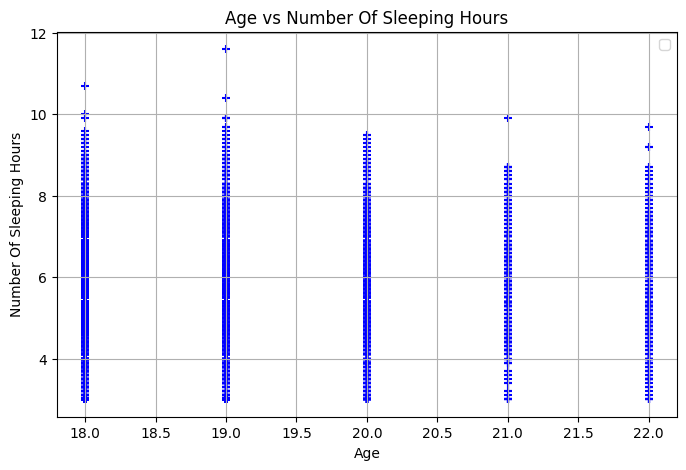

In [ ]:
#Scatter plot of Age compared to Number Of Sleeping Hours
plt.figure(figsize=(8, 5))
plt.scatter(df["Age"], df["Sleep_Duration_Hours"], color='blue', marker='+')
plt.title('Age vs Number Of Sleeping Hours')
plt.legend()
plt.xlabel('Age')
plt.ylabel('Number Of Sleeping Hours')
plt.grid(True)
plt.show()

Observation: The older the person is, the less sleep they tend to get based off this dataset

/tmp/ipykernel_16283/3798965969.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


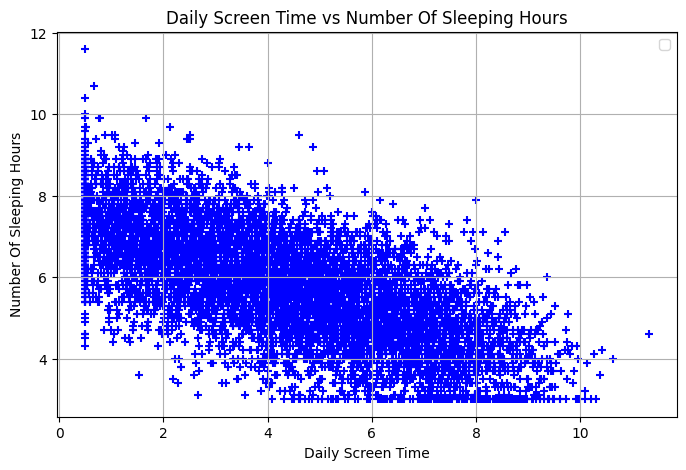

In [ ]:
#Scatter plot of Daily Screen Time compared to Number Of Sleeping Hours
plt.figure(figsize=(8, 5))
plt.scatter(df["Daily_Screen_Time_Hours"], df["Sleep_Duration_Hours"], color='blue', marker='+')
plt.title('Daily Screen Time vs Number Of Sleeping Hours')
plt.legend()
plt.xlabel('Daily Screen Time')
plt.ylabel('Number Of Sleeping Hours')
plt.grid(True)
plt.show()

Observation: As screen time increases, number of sleeping hours tends to decrease

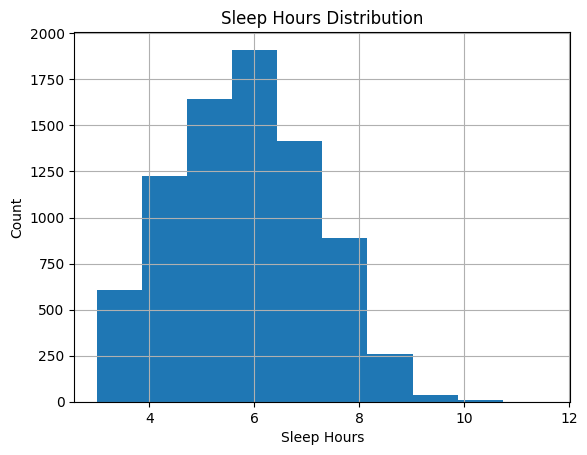

In [ ]:
#Sleep Hour Histogram
df["Sleep_Duration_Hours"].hist()
plt.title("Sleep Hours Distribution")
plt.xlabel("Sleep Hours")
plt.ylabel("Count")
plt.show()

Observations: This distribution is relatively symmetric, slightly skewed to the right, indicating that most individuals tend to get between 4 and 8 hours of sleep.

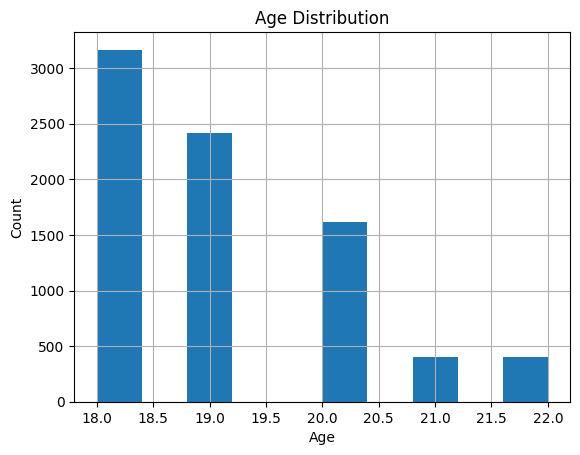

In [ ]:
#Age Histogram
df["Age"].hist()
plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

Observation: The vast majority of the people in this dataset are between 18 and 20 years old, with a couple being between 21 and 22

Text(0.5, 0, 'Anxiety Score')

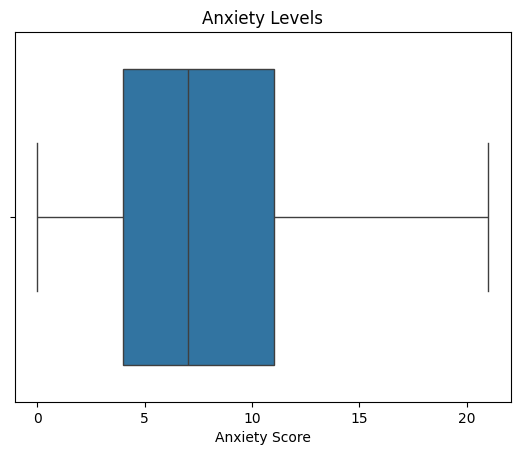

In [ ]:
#Boxplot of Anxiety Scores
sns.boxplot(x='GAD_7_Score', data=df)
plt.title('Anxiety Levels')
plt.xlabel('Anxiety Score')

Observation: Most indiviudals tend to have an anxiety score between 4 and 11

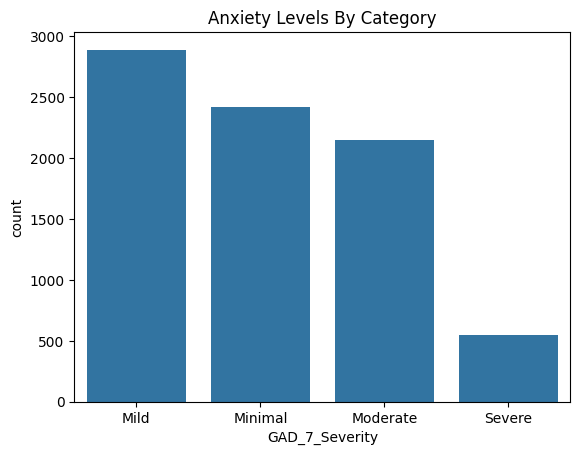

In [ ]:
#Displaying a countplot of anxiety levels
sns.countplot(x='GAD_7_Severity', data=df)
plt.title('Anxiety Levels By Category')
plt.show()

Observation: Most individuals in this datset either have mild, minimal, or moderate anxiety with a couple having severe anxiety

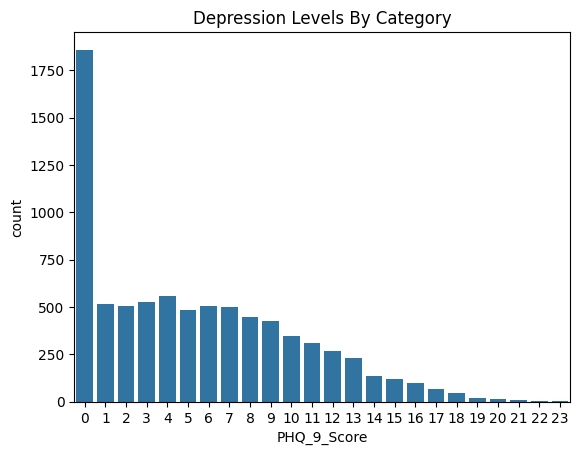

In [ ]:
#Displaying a countplot of depression levels
sns.countplot(x="PHQ_9_Score", data=df)
plt.title('Depression Levels By Category')
plt.show()

Observations: The most common result is to have a depression score of 0. A lot of people in this dataset have a score between a 1 and a 13, with very few people having a score between a 14 and a 23.

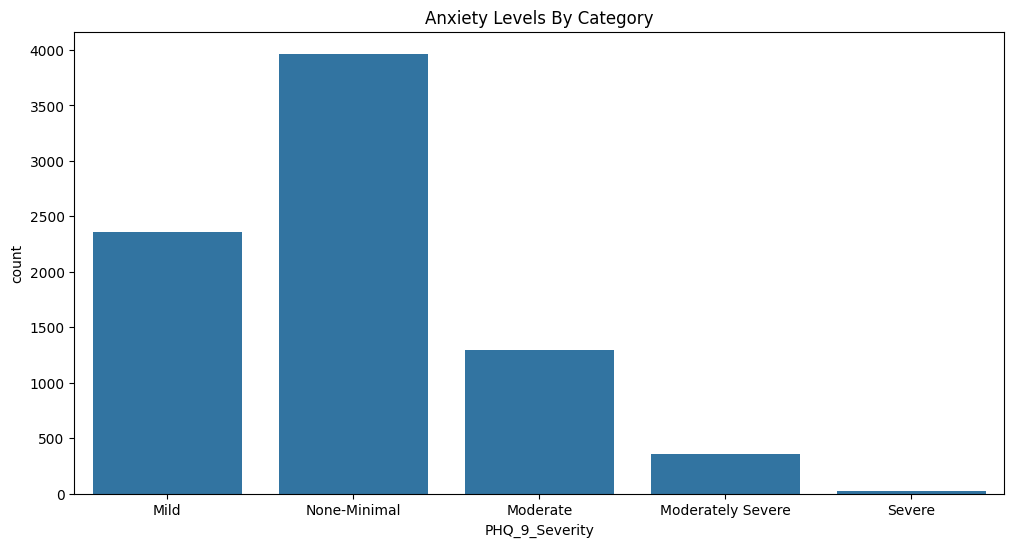

In [ ]:
#Displaying a countplot of depression levels
plt.figure(figsize=(12, 6))
sns.countplot(x='PHQ_9_Severity', data=df)
plt.title('Anxiety Levels By Category')
plt.show()

Observations: The most common result based off this dataset is to none to minimal depression with some having mild and moderate depression. Very few indivudals either have moderately severe or severe depression.

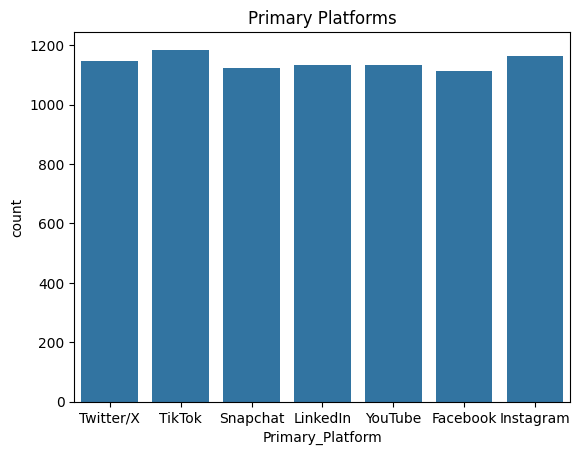

In [ ]:
#Displaying a countplot of Primary platforms
sns.countplot(x='Primary_Platform', data=df)
plt.title('Primary Platforms')
plt.show()

Observation: It is relatively balanced as to what platforms users are using the most. Tiktok has a slight edge.

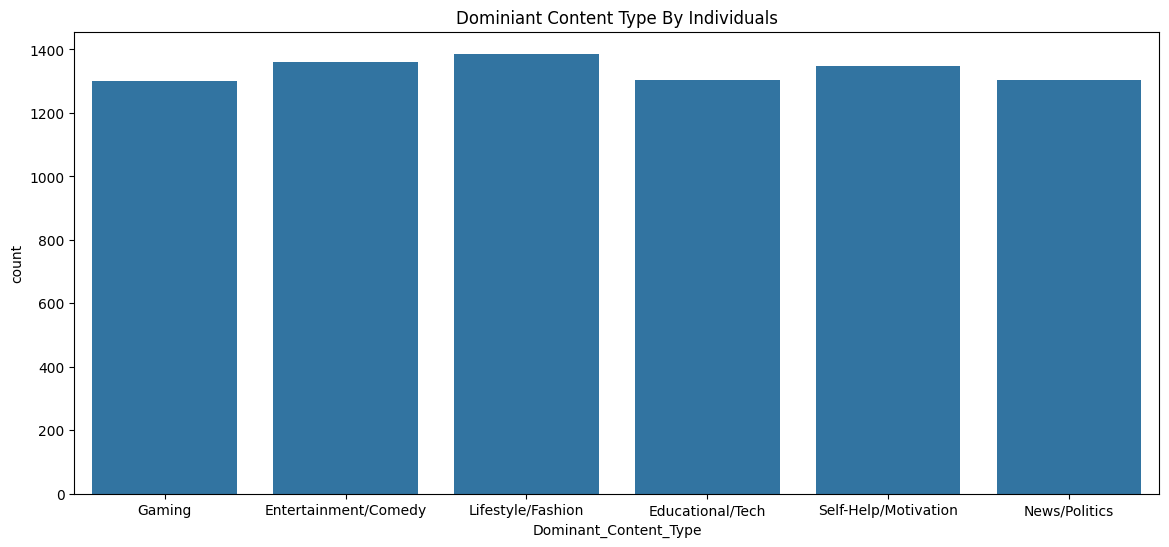

In [ ]:
#Displaying a countplot of Dominant platforms
plt.figure(figsize=(14, 6))
sns.countplot(x='Dominant_Content_Type', data=df)
plt.title('Dominiant Content Type By Individuals')
plt.show()

Observation: Indiviudals are looking at all sorts of content. Its relatively balanced but Lifestyle/Fashion has a slight edge.

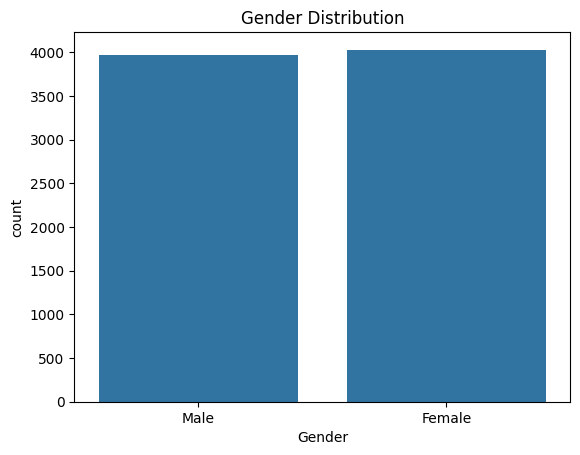

In [ ]:
#Generating a countplot of gender distribution
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

Observation: There are slightly more females than males contained in this dataset

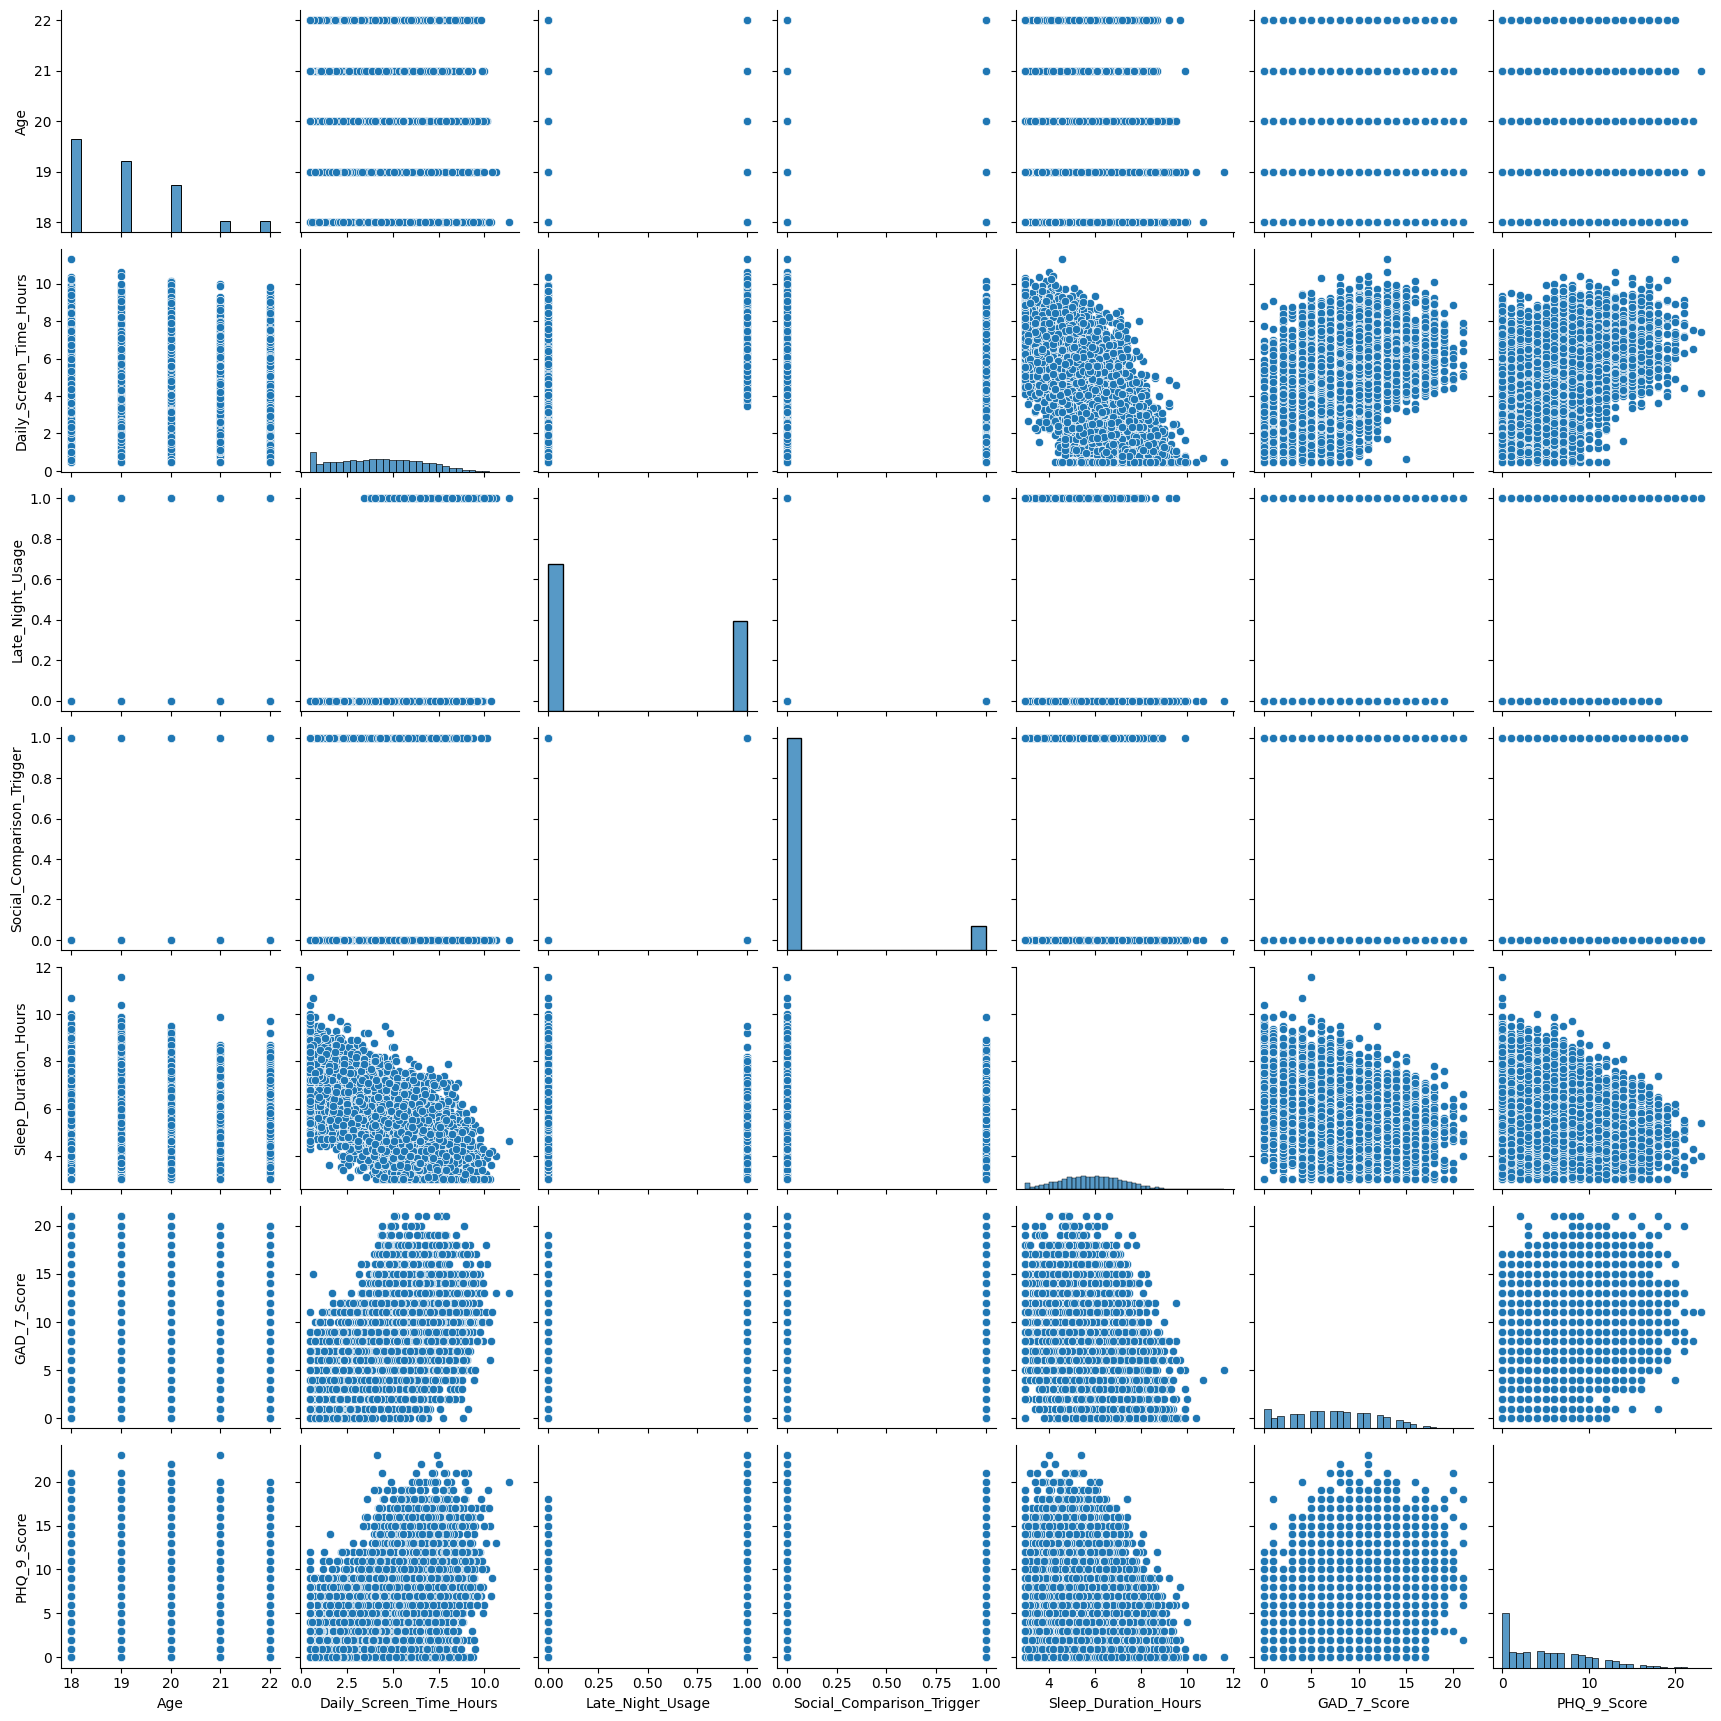

In [ ]:
#Checking for the correlations against all the numeric features
sns.pairplot(df)

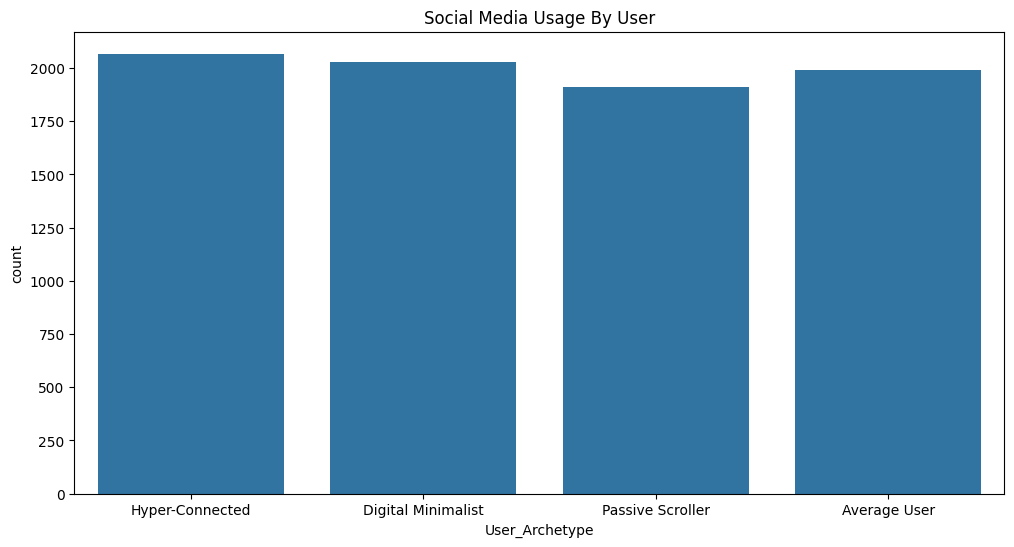

In [ ]:
#Generating a countplot of social media usage by users
plt.figure(figsize=(12, 6))
sns.countplot(x='User_Archetype', data=df)
plt.title('Social Media Usage By User')
plt.show()

Observation: It is relatively balanced as to how much a user uses social media but the most common result is for someone to be Hyper-Connected, meaning that they are on social media constantly.

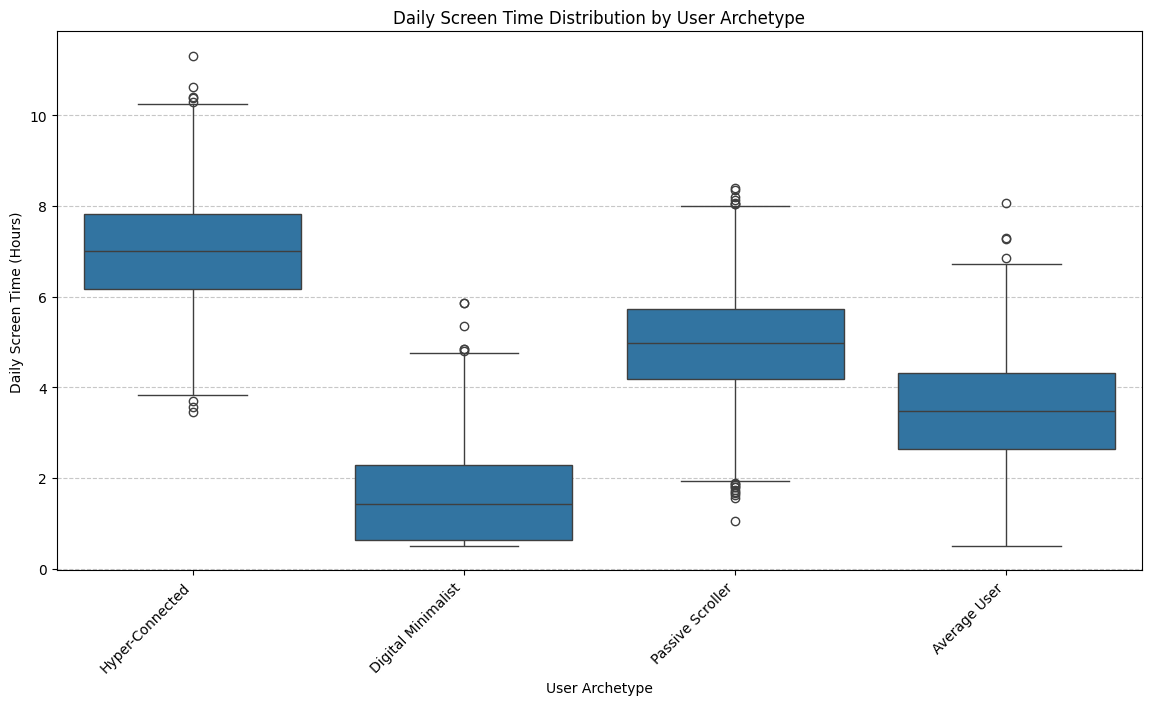

In [ ]:
#Boxplot of Daily Screen Time by User Archetype
plt.figure(figsize=(14, 7))
sns.boxplot(x='User_Archetype', y='Daily_Screen_Time_Hours', data=df)
plt.title('Daily Screen Time Distribution by User Archetype')
plt.xlabel('User Archetype')
plt.ylabel('Daily Screen Time (Hours)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Observation: This boxplot visualizes the distribution of daily screen time for each user archetype. We can see several metrics regarding the median, mean, and the IQR (interquartile range). As expected, hyper-connected indivudals consume the most amount of screentime on average (6-8 hours), while digital-minimalists consume the least amount of sreen time with 0-2 hours on average.

In [ ]:
#Checking for missing values
df.isnull().sum()

,0
User_ID,0
Age,0
Gender,0
User_Archetype,0
Primary_Platform,0
Daily_Screen_Time_Hours,0
Dominant_Content_Type,0
Activity_Type,0
Late_Night_Usage,0
Social_Comparison_Trigger,0


Observation: No missing values appear in this dataset

In [ ]:
#Pulling the data information back up
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 15 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   User_ID                    8000 non-null   object 
 1   Age                        8000 non-null   int64  
 2   Gender                     8000 non-null   object 
 3   User_Archetype             8000 non-null   object 
 4   Primary_Platform           8000 non-null   object 
 5   Daily_Screen_Time_Hours    8000 non-null   float64
 6   Dominant_Content_Type      8000 non-null   object 
 7   Activity_Type              8000 non-null   object 
 8   Late_Night_Usage           8000 non-null   int64  
 9   Social_Comparison_Trigger  8000 non-null   int64  
 10  Sleep_Duration_Hours       8000 non-null   float64
 11  GAD_7_Score                8000 non-null   int64  
 12  GAD_7_Severity             8000 non-null   object 
 13  PHQ_9_Score                8000 non-null   int64

In [ ]:
df.drop("User_ID", axis=1)

,Age,Gender,User_Archetype,Primary_Platform,Daily_Screen_Time_Hours,Dominant_Content_Type,Activity_Type,Late_Night_Usage,Social_Comparison_Trigger,Sleep_Duration_Hours,GAD_7_Score,GAD_7_Severity,PHQ_9_Score,PHQ_9_Severity
0,18,Male,Hyper-Connected,Twitter/X,8.50,Gaming,Active,0,0,3.9,9,Mild,5,Mild
1,20,Male,Digital Minimalist,TikTok,0.50,Gaming,Active,0,0,5.5,0,Minimal,8,Mild
2,18,Female,Digital Minimalist,Snapchat,0.91,Gaming,Active,0,0,8.9,1,Minimal,3,None-Minimal
3,18,Female,Hyper-Connected,Snapchat,7.43,Gaming,Active,1,0,6.2,13,Moderate,0,None-Minimal
4,18,Male,Hyper-Connected,LinkedIn,4.94,Entertainment/Comedy,Active,1,0,5.3,13,Moderate,10,Moderate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7995,21,Female,Hyper-Connected,TikTok,5.62,Gaming,Active,1,0,5.7,6,Mild,10,Moderate
7996,18,Male,Digital Minimalist,YouTube,3.15,News/Politics,Active,0,0,6.3,0,Minimal,12,Moderate
7997,18,Male,Hyper-Connected,YouTube,7.47,Gaming,Active,1,0,6.1,12,Moderate,14,Moderate
7998,18,Female,Hyper-Connected,Instagram,8.45,Self-Help/Motivation,Active,0,1,4.3,11,Moderate,2,None-Minimal


In [ ]:
#Dropping the User_Archytype column since thats going to be used as the target variable
X = df.drop("User_Archetype", axis= 1)
y = df["User_Archetype"]


In [ ]:
#One-Hot Encoding Step using the get dummies method
X = pd.get_dummies(X, drop_first=True)

In [ ]:
#Splitting the data, we are using stratify=y since this is going to be a classification problem

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=100, stratify=y)


In [ ]:
#Checking the shape
X.shape

(8000, 8026)

Deliverables 1 & 2 Summary:

We first imported the dataset into the notebook and analyzed each of the categorical and numerical features. From this dataset, we notice that there are 8000 instances with 15 different columns. From those columns, 8 of them are categorical and 7 are numerical. Then we analyzed the summary statistics and the correlations between all the numeric variables. After that, we decided to create several visualizations looking at the distributions of the numeric variables and how each of them impacts one another. In addition, we made some visualizations regarding the categorical variables. We found a lot of key findings using these processes.

First, we noticed that age and daily screen time seem to affect sleep. Older people tend to get less sleep and daily screen time also has a negative impact on sleep.

Then we found that most individuals in this dataset tend to get between 4 and 8 hours of sleep.

After that, we analyzed the metrics regarding anxiety and depression. We found that most individuals in this dataset either have none to moderate anxiety with very few having severe anxiety. When it comes to depression levels, most individuals have no depression or very minimal/mild cases of depression. Very few have moderate or severe depression.

Then we looked to see what platforms people in this dataset are using the most. Its relatively even among all the platforms.

After that, we looked to see what type of content dominates in this dataset. Its relatively even with Lifestyle/Fashion having a slight edge.

Then we made a pairplot showing the relationships across all the numeric features stacked up against one another.

Next, we looked at social media usage by users. Its relatively balanced but the Hyper-Connected category slightly edges the others. This means that the most common result based off this dataset is for a user to be active on social media.

After that, we made a visualization to see how many hours users are on social media based on their social media usage category. Hyper-Connected dominates social media usage time with 6-8 hours a day while Digital-Minimalists contain the least amount of time on social media with 1-2 hours on average.

We then checked to see if there were any missing values and we did not find any.

Based off all the analysis, we decided that we should go with User_Archetype as the target variable so we can predict how much someone uses social media. We find this to be the most impactful variable to predict based off the dataset. Since this is going to be our target variable, were going to use the classification approach to analyze this further.  

Next, we separated the User_Archtype column as the target variable and removed it from the feature set. Then we used the get_dummies() method to One-Hot-Encode the data. It was used to convert categorical variables into numerical format, as most machine learning algorithms require numeric input and cannot interpret categorical strings directly. It also ensures that all models use the same consistent numerical feature representation across the training and testing data.

Then we split the training and testing data using a 75/25 ratio. This means that 75% of the data is used for the training and 25% of the data will be used for the testing. The 25% test set is treated as a holdout “vault” dataset and will not be used during model training or tuning to ensure unbiased final evaluation. We then set the random_state to 100 and added the stratify=y parameter in since this is going to be a classification problem. That parameter is necessary to proceed with classification. After applying the One-Hot Encoding, the feature space increased substantially because the categorical variables were expanded into many binary columns. We verified the transformed feature matrix shape after encoding to confirm that the process was applied correctly.  

We did not notice many significant outliers within this dataset. The only metrics that had noticeable outliers were anxiety level and depression level. Very few people were recorded with extreme cases of anxiety or depression. We were able to identify this by using several visualizations.

We also decided to drop the user_id column since it is a unique identifier with no predictive value and could introduce noise or overfitting into the model.

We ended up choosing this dataset because it contains very useful information regarding social media usage. It dives into a deep analysis containing several key metrics that accurately describes how much someone uses social media. In addition, we found that all these metrics accurately reflect real world knowledge when it comes to social media and anxiety and depression rates. That fact can be supported by the large sample size of this dataset. Another reason why we choose this dataset is because it is very clean and organized and doesn't contain any missing values.




##KNN Model - Jacob

In [ ]:
#split training data
X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=100,
    stratify=y_train
)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

#fit on subtrain, transform validation
X_subtrain_scaled = scaler.fit_transform(X_subtrain)
X_validation_scaled = scaler.transform(X_validation)

#scale full training and test sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [ ]:
#train KNN model
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_subtrain_scaled, y_subtrain)

KNeighborsClassifier()

In [ ]:
#evaluate model
from sklearn.metrics import accuracy_score, classification_report

y_pred = knn.predict(X_validation_scaled)

print("Validation Accuracy:", accuracy_score(y_validation, y_pred))
print(classification_report(y_validation, y_pred))


Validation Accuracy: 0.6908333333333333
                    precision    recall  f1-score   support

      Average User       0.46      0.57      0.50       299
Digital Minimalist       0.67      0.56      0.61       305
   Hyper-Connected       0.78      0.72      0.75       310
  Passive Scroller       0.93      0.92      0.93       286

          accuracy                           0.69      1200
         macro avg       0.71      0.69      0.70      1200
      weighted avg       0.71      0.69      0.70      1200



In [ ]:
k_values = range(1, 8)

accuracies = []
train_accuracies = []

X_sub_small = X_subtrain_scaled[:2000]
y_sub_small = y_subtrain[:2000]

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k, n_jobs=-1)
    model.fit(X_sub_small, y_sub_small)

    #predictions
    train_pred = model.predict(X_sub_small)
    val_pred = model.predict(X_validation_scaled)

    #store accuracies
    train_accuracies.append(accuracy_score(y_sub_small, train_pred))
    accuracies.append(accuracy_score(y_validation, val_pred))

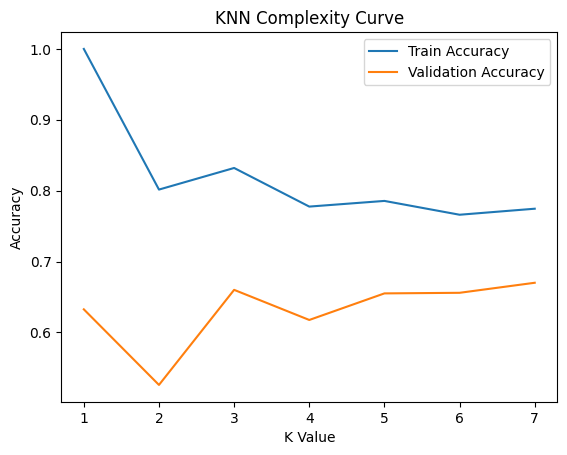

In [ ]:
plt.plot(k_values, train_accuracies, label="Train Accuracy")
plt.plot(k_values, accuracies, label="Validation Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Complexity Curve")
plt.legend()
plt.show()

In [ ]:
#best K
best_k = k_values[np.argmax(accuracies)]
print("Best K:", best_k)

#train final model
final_model = KNeighborsClassifier(n_neighbors=best_k)
final_model.fit(X_train_scaled, y_train)

final_pred = final_model.predict(X_test_scaled)

print("Test Accuracy:", accuracy_score(y_test, final_pred))
print(classification_report(y_test, final_pred))

Best K: 7
Test Accuracy: 0.72
                    precision    recall  f1-score   support

      Average User       0.49      0.54      0.51       498
Digital Minimalist       0.68      0.67      0.68       508
   Hyper-Connected       0.81      0.73      0.77       517
  Passive Scroller       0.94      0.95      0.95       477

          accuracy                           0.72      2000
         macro avg       0.73      0.72      0.73      2000
      weighted avg       0.73      0.72      0.72      2000



Observation: we are creating subtrain sets for the training data and validation sets for the testing data



1.   List item
2.   List item



In [ ]:
#Conduct inner split of training set  sub-training set & validation set
X_subtrain, X_validation, y_subtrain, y_validation = train_test_split(
    X_train, y_train, test_size=0.2, random_state=100, stratify=y_train)

In [ ]:
#Scale the sub-training set.
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, precision_score, recall_score
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()
scaler.fit(X_subtrain)
X_subtrain_scaled_8026 = scaler.transform(X_subtrain)
X_validation_scaled_8026 = scaler.transform(X_validation)
X_test_scaled = scaler.transform(X_test)

# learning a Logistic Regression model on the scaled training data
lr_scaled = LogisticRegression()
lr_scaled.fit(X_subtrain_scaled_8026, y_subtrain)

LogisticRegression()

In [ ]:
#Add polynomial features. (If > 15 features, select top 10-12 features, then add polynomial features)
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k=12)
# Fit the selector on the full-featured scaled subtrain data (8026 features)
selector.fit(X_subtrain_scaled_8026, y_subtrain)

# Transform subtrain and validation sets (output will have 12 features)
X_subtrain_selected = selector.transform(X_subtrain_scaled_8026)
X_validation_selected = selector.transform(X_validation_scaled_8026)
X_test_selected = selector.transform(X_test_scaled)

/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:111: UserWarning: Features [   7   12   17 ... 8000 8001 8005] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
/usr/local/lib/python3.12/dist-packages/sklearn/feature_selection/_univariate_selection.py:112: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


feature selection was performed using SelectKBest to retain the top 12 most relevant predictors.

In [ ]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)

# Use the selected features (12 features) for polynomial transformation
poly.fit(X_subtrain_selected)
X_subtrain_poly = poly.transform(X_subtrain_selected)
X_validation_poly = poly.transform(X_validation_selected)
X_test_poly = poly.transform(X_test_selected)

Afterward, polynomial features of degree 2 were generated.

In [ ]:
#Use a loop to tune the parameters.
from sklearn.linear_model import LogisticRegression

C_values = [0.01, 0.1, 1, 10]

for c in C_values:
    model = LogisticRegression(
        penalty='l1',
        solver='liblinear',
        C=c,
        max_iter=1000
    )

    model.fit(X_subtrain_poly, y_subtrain)

    train_score = model.score(X_subtrain_poly, y_subtrain)
    val_score = model.score(X_validation_poly, y_validation)

    print(f"C: {c}")
    print(f"Train Accuracy: {train_score:.3f}")
    print(f"Validation Accuracy: {val_score:.3f}")
    print("------")

C: 0.01
Train Accuracy: 0.859
Validation Accuracy: 0.877
------
C: 0.1
Train Accuracy: 0.860
Validation Accuracy: 0.884
------
C: 1
Train Accuracy: 0.863
Validation Accuracy: 0.880
------
C: 10
Train Accuracy: 0.865
Validation Accuracy: 0.876
------


A Logistic Regression model with L1 regularization was implemented to perform classification while also enabling feature selection. A loop was used to tune the regularization parameter C, testing values of 0.01, 0.1, 1, and 10. The best performance was achieved at C = 0.1, which produced the highest validation accuracy of 0.884.

In [ ]:
best_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=0.1
)
best_model.fit(X_subtrain_poly, y_subtrain)

LogisticRegression(C=0.1, penalty='l1', solver='liblinear')

In [ ]:
test_score = best_model.score(X_test_poly, y_test)
print("Test Accuracy:", test_score)

Test Accuracy: 0.8585


a training accuracy of 0.860 and a test accuracy of 0.8575. The relatively small difference between training, validation, and test accuracies shows the model functions well, with only slight overfitting.

In [ ]:
#List the specific features zeroed out by L1 penalty.
import numpy as np

feature_names = poly.get_feature_names_out()

for name, coef in zip(feature_names, best_model.coef_[0]):
    if coef == 0:
        print(name)

x2
x3
x4
x6
x7
x8
x9
x10
x11
x0 x3
x0 x4
x0 x5
x0 x8
x0 x9
x0 x10
x0 x11
x1^2
x1 x3
x1 x4
x1 x5
x1 x6
x1 x7
x1 x8
x1 x10
x1 x11
x2^2
x2 x3
x2 x4
x2 x5
x2 x6
x2 x8
x2 x9
x2 x11
x3 x4
x3 x5
x3 x6
x3 x7
x3 x8
x3 x11
x4^2
x4 x5
x4 x6
x4 x7
x4 x8
x4 x9
x4 x10
x4 x11
x5 x6
x5 x7
x5 x8
x5 x9
x5 x10
x5 x11
x6^2
x6 x7
x6 x8
x6 x9
x6 x10
x6 x11
x7^2
x7 x8
x7 x9
x7 x10
x7 x11
x8 x9
x8 x10
x8 x11
x9 x10
x9 x11
x10^2
x10 x11
x11^2


Overall, the L1-regularized Logistic Regression model demonstrated strong performance while reducing model complexity through feature selection.

##RF Model - Austin


In [ ]:
#Creating a pipline with StandardScaler() and RandomForestClassifier()
pipe = make_pipeline(
    StandardScaler(),
    RandomForestClassifier(random_state=100))

In [ ]:
#Define the parameter grid as randomforestclassifier_n_estimators: [100, 200, 300], randomforestclassifier_max_depth: [None, 5, 10], and randomforestclassifier_min_samples_split: [2, 5, 10]
param_grid = {"randomforestclassifier__n_estimators": [10, 20, 30],
              "randomforestclassifier__max_depth": [2, 3, 5],
              "randomforestclassifier__min_samples_split": [2, 5, 10],
              }

In [53]:
#Running the GridSearchCV based on the Pipeline Random Forest Classifier
gridrf = GridSearchCV(pipe, param_grid=param_grid, cv=5, n_jobs=-1)
gridrf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('standardscaler', StandardScaler()),
                                       ('randomforestclassifier',
                                        RandomForestClassifier(random_state=100))]),
             n_jobs=-1,
             param_grid={'randomforestclassifier__max_depth': [2, 5, 10],
                         'randomforestclassifier__min_samples_split': [2, 5,
                                                                       10],
                         'randomforestclassifier__n_estimators': [100, 200,
                                                                  300]})

In [54]:
#Checking the Pipeline Random Forest Classifier Parameters
print("Best parameters: {}".format(gridrf.best_params_))

Best parameters: {'randomforestclassifier__max_depth': 10, 'randomforestclassifier__min_samples_split': 2, 'randomforestclassifier__n_estimators': 300}


Observation: the best parameters are max_deph = 10, min_samples_split = 2, and n_estimators = 300

In [55]:
#Checking the Pipeline Random Forest Classifer training and testing score
print("Train-set score (Random Forest Classifier): {:.2f}".format(gridrf.score(X_train, y_train)))
print("Test-set score (Random Forest Classifier): {:.2f}".format(gridrf.score(X_test, y_test)))

Train-set score (Random Forest Classifier): 0.73
Test-set score (Random Forest Classifier): 0.72


Observation: With these parameters put in place, the RF model has a training score of 0.73 and a testing score of 0.72. This model is slightly overfitting, meaning that the model is slightly complex. Overall, the model is performing ok.

In [63]:
#Working on the feature importance plot
def plot_feature_importances_df_sorted(model):
    plt.figure(figsize=(10, 6))

    rf_model = model.named_steps['randomforestclassifier']
    n_features = X.shape[1]

    # Get feature importances and sort them
    sorted_idx = rf_model.feature_importances_.argsort()
    sorted_importances = rf_model.feature_importances_[sorted_idx]
    sorted_feature_names = X.columns[sorted_idx]

    plt.barh(range(n_features), sorted_importances, align='center')
    plt.yticks(np.arange(n_features), sorted_feature_names)
    plt.xlabel("Feature importance")
    plt.ylabel("Feature")
    plt.ylim(-1, n_features)
    plt.title("Feature Importances (Sorted)")
    plt.show()

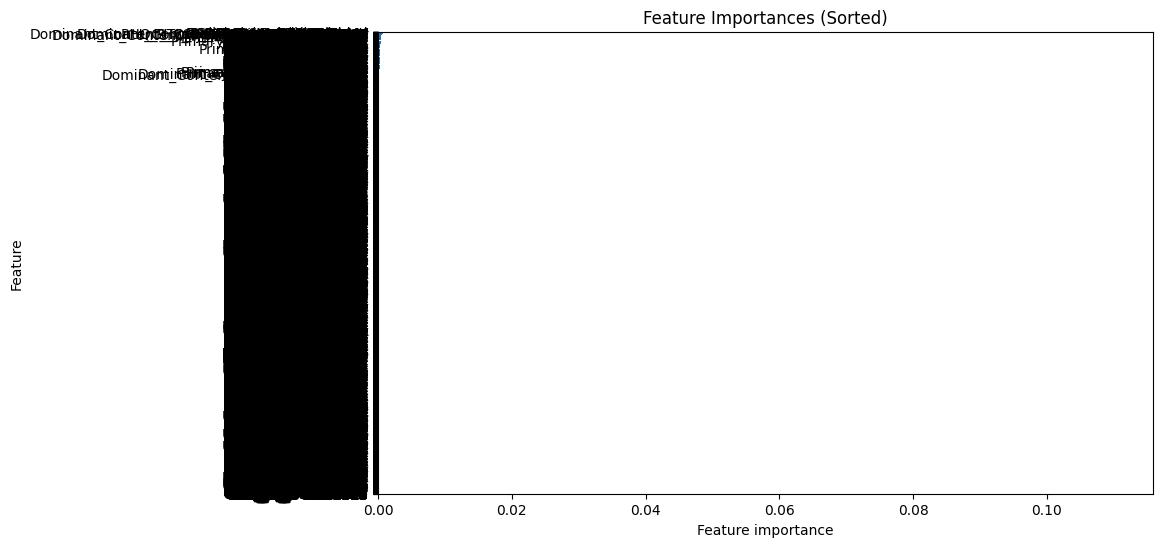

In [64]:
#Displaying the featue importance plot
plot_feature_importances_df_sorted(gridrf.best_estimator_)

##Deliverable 4, The Confusion Matirx